<a href="https://colab.research.google.com/github/kahinidesai/mars-organic-survival/blob/main/Goldilocks_Preservation_Depth.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Modelling Organic Molecule Survival on Mars: Finding the Goldilocks Preservation Depth**

**Kahini Desai** | April 2026

A computational astrobiology study using real Curiosity (Gale Crater) and Perseverance (Jezero Crater) rover data from the NASA Planetary Data System.

### 1. First-Order Decay Model

Glycine is the simplest amino acid and is crucial for creating proteins. Its presence is essential for biological processes, making it a target in the search for extraterrestrial life.

On Mars, glycine faces rapid degradation through UV radiation, ionizing radiation, and thermal processes. However, just beneath the surface, UV flux drops dramatically and temperature stabilises — creating potentially optimal preservation conditions. This project models where exactly that sweet spot lies.

The governing equation is first-order exponential decay: **C(t) = C₀ e⁻ᵏᵗ**, where each degradation mechanism destroys a fixed *fraction* of remaining molecules per unit time, producing an exponential curve rather than a straight line.

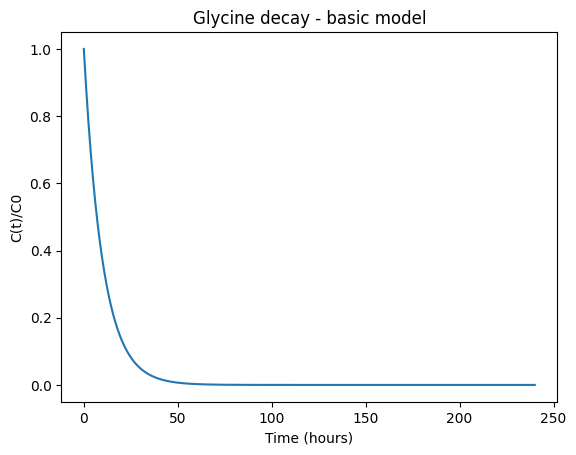

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for glycine
C0 = 1.0  # normalized concentration
k = 0.1   # degradation rate (per hour) - placeholder for now

# Time array: 0 to 240 hours (10 Mars days)
t = np.linspace(0, 240, 1000)

# The decay equation
C = C0 * np.exp(-k * t)

plt.plot(t, C)
plt.xlabel('Time (hours)')
plt.ylabel('C(t)/C0')
plt.title('Glycine decay - basic model')
plt.show()

### 2. Degradation Rate Constants

Three mechanisms destroy glycine on Mars:
- **UV photolysis**: k_UV = σ × F_UV, where σ = 1.2 × 10⁻¹⁷ cm² is the absorption cross-section
- **Ionizing radiation**: k_rad = α × D_rate, where α = 2.5 × 10⁻³ Gy⁻¹ and D_rate = 0.076 × 10⁻³ Gy/hour (from Curiosity RAD instrument)
- **Thermal degradation**: governed by the Arrhenius equation k = A e⁻ᴱᵃ/ᴿᵀ

We calculate k_UV and k_rad to determine which mechanism dominates at the surface.

In [17]:

# 1. UV photolysis: k_UV = sigma * F_UV
sigma = 1.2e-17        # absorption cross-section (cm²) - how easily UV breaks glycine
F_UV = 2.8e14          # UV photon flux on Mars surface (photons/cm²/s)
k_UV = sigma * F_UV    # per second

# 2. Radiation: k_rad = alpha * dose_rate
alpha = 2.5e-3         # sensitivity to radiation (per Gray)
dose_rate = 0.076e-3   # Gy/hour at Gale Crater (from Curiosity RAD instrument)
k_rad = alpha * dose_rate  # per hour

# 3. Print them so you can see which dominates
print(f"k_UV = {k_UV:.4e} per second")
print(f"k_UV = {k_UV*3600:.4e} per hour")  # convert to per hour
print(f"k_rad = {k_rad:.4e} per hour")

k_UV = 3.3600e-03 per second
k_UV = 1.2096e+01 per hour
k_rad = 1.9000e-07 per hour


### Goldilocks Depth Model

k_UV is 63 million times greater than k_rad, meaning UV is overwhelmingly the dominant destruction mechanism at the Martian surface. Below the surface, survival increases dramatically as UV flux drops to near zero within just a few centimetres of regolith.

The Goldilocks depth is the subsurface depth where half-life is maximised — balancing UV attenuation (Beer-Lambert law: F_UV(z) = F_surface × e⁻ᶻ/λ, where λ = 0.1 cm) against geothermal heating (T(z) = 210 + 0.1z K). The peak represents the point where UV has been fully attenuated but thermal degradation has not yet significantly accelerated.

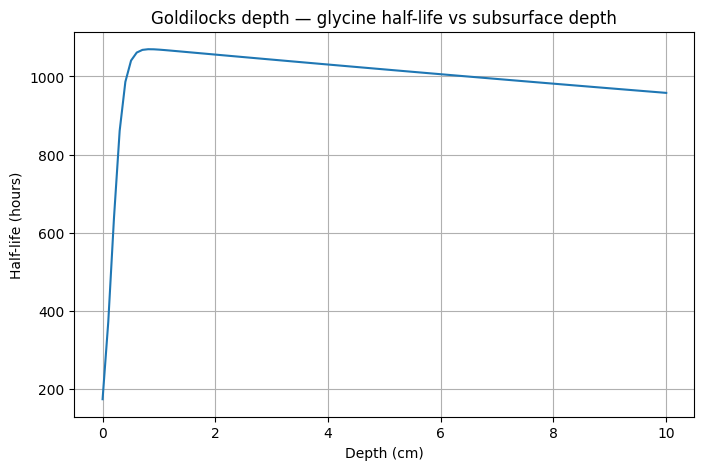

In [18]:
# === GOLDILOCKS DEPTH MODEL ===

depths = np.linspace(0, 10, 100)  # 0 to 10 cm

# UV attenuation with depth (Beer-Lambert)
F_UV_z = F_UV * np.exp(-depths / 0.1)
k_UV_z = sigma * F_UV_z

# Radiation attenuation with depth
k_rad_z = k_rad * np.exp(-depths / 3.0)

# Thermal rate - constant with depth (subsurface mean temp)
T_sub = 210  # Kelvin
T = 210 + 0.1 * depths
k_thermal_z = 1e8 * np.exp(-45000 / (8.314 * T)) * np.ones_like(depths)

# Total rate at each depth
k_total_z = k_UV_z + k_rad_z + k_thermal_z

# Half life at each depth in hours
half_life_z = np.log(2) / k_total_z

# Plot
plt.figure(figsize=(8,5))
plt.plot(depths, half_life_z)
plt.xlabel('Depth (cm)')
plt.ylabel('Half-life (hours)')
plt.title('Goldilocks depth — glycine half-life vs subsurface depth')
plt.grid(True)
plt.show()

In [19]:
optimal_depth = depths[np.argmax(half_life_z)]
print(f"Goldilocks depth: {optimal_depth:.2f} cm")

Goldilocks depth: 0.81 cm


### 3. Real Data Acquisition — Curiosity REMS

UV flux data was downloaded from the NASA Planetary Data System (PDS) archive. The corrected UV dataset (DATA_UV_CORRECTED) from the Rover Environmental Monitoring Station (REMS) on Curiosity was used, covering sols 1–100 at Gale Crater. REMS samples at 1 Hz cadence, producing approximately 22,000 measurements per sol.

In [20]:
import urllib.request

base_url = "https://atmos.nmsu.edu/PDS/data/mslrem_1001/DATA_UV_CORRECTED/"
files = ["REMS_UVS_0001_0100.TAB"]
for f in files:
    print(f"Downloading {f}...")
    urllib.request.urlretrieve(base_url + f, f)
    print(f"Done.")

Done.


### 4. Data Loading and Column Assignment

The REMS UV data is a CSV with 24 columns. The key variables are SOL_NUMBER, LMST_HOUR (local time), and UV_ABC (combined broadband UV irradiance in W/m²). Nighttime readings are flagged as -999 when solar zenith angle exceeds 55°.

In [22]:
import pandas as pd

col_names = ['SOL_NUMBER', 'LMST_HOUR', 'SOLAR_ZENITH_ANGLE',
             'SOLAR_AZIMUTH_ANGLE', 'ROVER_YAW', 'ROVER_PITCH',
             'ROVER_ROLL', 'ROVER_VELOCITY', 'MASTHEAD_AZIMUTH',
             'MASTHEAD_ELEVATION', 'ARM_STILL', 'ARM_STOWED',
             'UV_A', 'UV_B', 'UV_C', 'UV_ABC', 'UV_D', 'UV_E',
             'UV_A_UNCERTAINTY', 'UV_B_UNCERTAINTY', 'UV_C_UNCERTAINTY',
             'UV_ABC_UNCERTAINTY', 'UV_D_UNCERTAINTY', 'UV_E_UNCERTAINTY']

df = pd.read_csv('REMS_UVS_0001_0100.TAB',
                 names=col_names,
                 skipinitialspace=True)

print(df.shape)
print(df[['SOL_NUMBER', 'LMST_HOUR', 'UV_ABC']].head(10))

(2242660, 24)
   SOL_NUMBER  LMST_HOUR    UV_ABC
0           1  13.220833  1.128496
1           1  13.221111  1.111548
2           1  13.221389  1.104325
3           1  13.221667  1.113722
4           1  13.221944  1.102558
5           1  13.222222  1.113078
6           1  13.222500  1.106046
7           1  13.222778  1.094005
8           1  13.223056  1.105188
9           1  13.223333  1.112764


In [23]:
print(df[['SOL_NUMBER', 'UV_ABC']].describe())
print(df['SOL_NUMBER'].unique()[:10])

         SOL_NUMBER        UV_ABC
count  2.242660e+06  2.242660e+06
mean   5.991482e+01 -6.510738e+02
std    2.502829e+01  4.815661e+02
min    1.000000e+00 -9.990000e+02
25%    3.900000e+01 -9.990000e+02
50%    6.200000e+01 -9.990000e+02
75%    8.100000e+01  1.305091e+01
max    1.000000e+02  2.475824e+01
[ 1  9 10 11 12 13 14 15 16 17]


### 5. Data Cleaning

Invalid readings (-999) are removed. These represent nighttime measurements when the UV sensor cannot operate. We expect to lose roughly 65% of rows since Mars nights are long.

In [24]:
df_clean = df[df['UV_ABC'] != -999]

print(f"Rows before cleaning: {len(df)}")
print(f"Rows after cleaning: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")

print(f"\nUV_ABC min: {df_clean['UV_ABC'].min():.4f} W/m²")
print(f"UV_ABC max: {df_clean['UV_ABC'].max():.4f} W/m²")
print(f"UV_ABC mean: {df_clean['UV_ABC'].mean():.4f} W/m²")

Rows before cleaning: 2242660
Rows after cleaning: 769179
Rows removed: 1473481

UV_ABC min: 0.8682 W/m²
UV_ABC max: 24.7582 W/m²
UV_ABC mean: 15.4324 W/m²


### 6. Unit Conversion — W/m² to photons/cm²/s

Our k_UV formula requires photon flux, but REMS measures energy flux in W/m². The conversion uses Planck's equation: F_photons = (F_watts × λ) / (h × c), with λ = 300 nm as an approximate mean UV wavelength across the 200–400 nm UV_ABC band. This approximation is noted as a limitation — a spectral-weighted mean would be more precise.

In [25]:
# Convert UV flux from W/m² to photons/cm²/s
h = 6.626e-34      # Planck's constant (J·s)
c = 3e8            # speed of light (m/s)
lambda_uv = 300e-9 # mean UV wavelength (m)

# Energy per photon
E_photon = h * c / lambda_uv

# Convert W/m² to W/cm²  then to photons/cm²/s
F_UV_real = (df_clean['UV_ABC'].mean() * 1e-4) / E_photon

print(f"Mean UV flux: {df_clean['UV_ABC'].mean():.4f} W/m²")
print(f"Converted to: {F_UV_real:.4e} photons/cm²/s")
print(f"Our assumed value was: {2.8e14:.4e} photons/cm²/s")
print(f"Difference: {((F_UV_real - 2.8e14)/2.8e14)*100:.1f}%")

Mean UV flux: 15.4324 W/m²
Converted to: 2.3291e+15 photons/cm²/s
Our assumed value was: 2.8000e+14 photons/cm²/s
Difference: 731.8%


### 7. Goldilocks Depth with Real Curiosity UV Data

We now replace the assumed UV flux with the real measured value. If real UV is stronger than assumed, the optimal depth will move deeper — more regolith is needed for effective shielding.

Goldilocks depth (assumed UV): 0.81 cm
Goldilocks depth (real Curiosity data): 1.01 cm


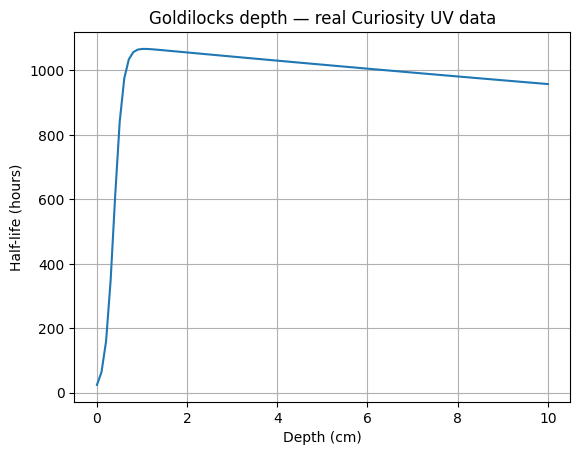

In [26]:
# Goldilocks model with REAL Curiosity data
F_UV_measured = F_UV_real  # from real data

depths = np.linspace(0, 10, 100)
F_UV_z = F_UV_measured * np.exp(-depths / 0.1)
k_UV_z = sigma * F_UV_z
k_rad_z = k_rad * np.exp(-depths / 3.0)
T_z = 210 + 0.1 * depths
k_thermal_z = 1e8 * np.exp(-45000 / (8.314 * T_z))
k_total_z = k_UV_z + k_rad_z + k_thermal_z
half_life_z = np.log(2) / k_total_z

optimal_depth_real = depths[np.argmax(half_life_z)]
print(f"Goldilocks depth (assumed UV): 0.81 cm")
print(f"Goldilocks depth (real Curiosity data): {optimal_depth_real:.2f} cm")

plt.plot(depths, half_life_z)
plt.xlabel('Depth (cm)')
plt.ylabel('Half-life (hours)')
plt.title('Goldilocks depth — real Curiosity UV data')
plt.grid(True)
plt.show()

### 8. Assumed vs Real UV — Visual Comparison

Plotting both Goldilocks curves on the same axes shows the effect of using real measurements versus theoretical estimates. The vertical dotted lines mark the optimal depth under each assumption.

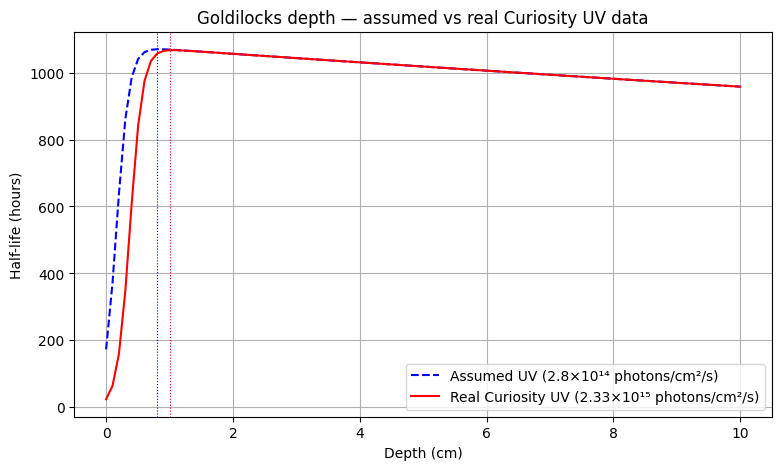

In [27]:
# Compare assumed vs real UV Goldilocks curves
depths = np.linspace(0, 10, 100)

# Assumed UV model
F_UV_assumed = 2.8e14
k_UV_assumed = sigma * F_UV_assumed * np.exp(-depths / 0.1)
k_total_assumed = k_UV_assumed + k_rad * np.exp(-depths/3.0) + 1e8 * np.exp(-45000/(8.314*(210+0.1*depths)))
half_life_assumed = np.log(2) / k_total_assumed

# Real UV model
k_UV_real = sigma * F_UV_real * np.exp(-depths / 0.1)
k_total_real = k_UV_real + k_rad * np.exp(-depths/3.0) + 1e8 * np.exp(-45000/(8.314*(210+0.1*depths)))
half_life_real = np.log(2) / k_total_real

plt.figure(figsize=(9,5))
plt.plot(depths, half_life_assumed, 'b--', label='Assumed UV (2.8×10¹⁴ photons/cm²/s)')
plt.plot(depths, half_life_real, 'r-', label='Real Curiosity UV (2.33×10¹⁵ photons/cm²/s)')
plt.axvline(0.81, color='blue', linewidth=0.8, linestyle=':')
plt.axvline(1.01, color='red', linewidth=0.8, linestyle=':')
plt.xlabel('Depth (cm)')
plt.ylabel('Half-life (hours)')
plt.title('Goldilocks depth — assumed vs real Curiosity UV data')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
plt.savefig('goldilocks_comparison.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

### 9. UV Flux Variation Across 100 Sols

Rather than using a single mean UV value, we examine how UV changes from sol to sol. Dust storms reduce UV flux dramatically, while clear days produce peak UV. This 10× variation (2.01–20.59 W/m²) drives corresponding shifts in the Goldilocks depth.

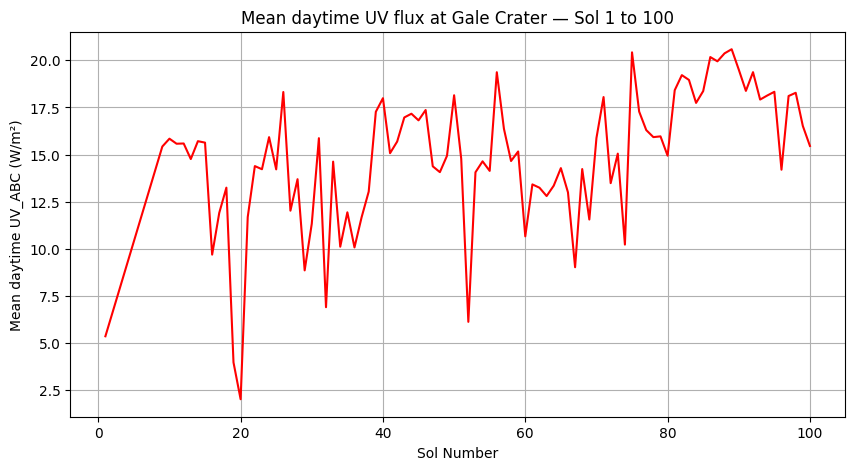

Highest UV sol: 89 (20.59 W/m²)
Lowest UV sol: 20 (2.01 W/m²)


In [29]:
# Average UV per sol
uv_per_sol = df_clean.groupby('SOL_NUMBER')['UV_ABC'].mean()

plt.figure(figsize=(10,5))
plt.plot(uv_per_sol.index, uv_per_sol.values, 'r-', linewidth=1.5)
plt.xlabel('Sol Number')
plt.ylabel('Mean daytime UV_ABC (W/m²)')
plt.title('Mean daytime UV flux at Gale Crater — Sol 1 to 100')
plt.grid(True)
plt.show()

print(f"Highest UV sol: {uv_per_sol.idxmax()} ({uv_per_sol.max():.2f} W/m²)")
print(f"Lowest UV sol: {uv_per_sol.idxmin()} ({uv_per_sol.min():.2f} W/m²)")

### 10. Sol-by-Sol Goldilocks Depth

Running the Goldilocks calculation independently for each sol reveals the dynamic nature of the preservation zone — it is not a fixed depth but fluctuates between 0.81 cm (dusty Sol 20) and 1.11 cm (clear Sol 89) with daily weather conditions.

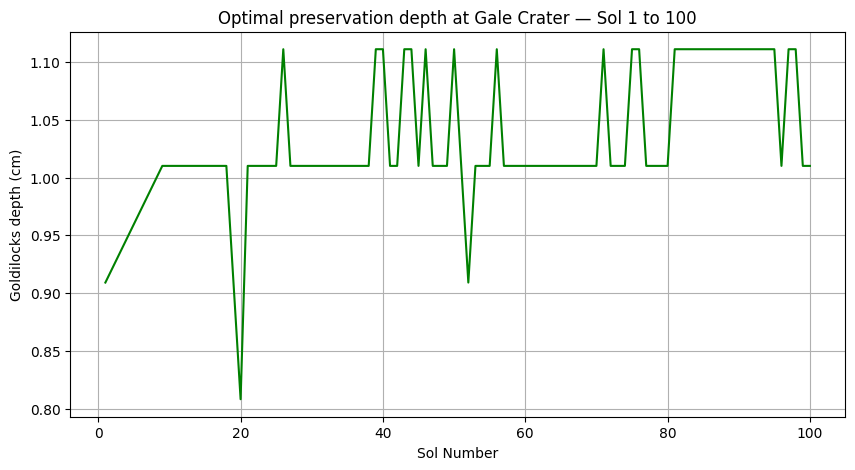

Mean Goldilocks depth: 1.04 cm
Min depth (dusty day): 0.81 cm
Max depth (clear day): 1.11 cm


In [30]:
# Goldilocks depth for every sol
goldilocks_per_sol = []

for sol in uv_per_sol.index:
    F_UV_sol = (uv_per_sol[sol] * 1e-4) / E_photon
    k_UV_z = sigma * F_UV_sol * np.exp(-depths / 0.1)
    k_total_z = k_UV_z + k_rad * np.exp(-depths/3.0) + 1e8 * np.exp(-45000/(8.314*(210+0.1*depths)))
    half_life_z = np.log(2) / k_total_z
    goldilocks_per_sol.append(depths[np.argmax(half_life_z)])

plt.figure(figsize=(10,5))
plt.plot(uv_per_sol.index, goldilocks_per_sol, 'g-', linewidth=1.5)
plt.xlabel('Sol Number')
plt.ylabel('Goldilocks depth (cm)')
plt.title('Optimal preservation depth at Gale Crater — Sol 1 to 100')
plt.grid(True)
plt.show()

print(f"Mean Goldilocks depth: {np.mean(goldilocks_per_sol):.2f} cm")
print(f"Min depth (dusty day): {np.min(goldilocks_per_sol):.2f} cm")
print(f"Max depth (clear day): {np.max(goldilocks_per_sol):.2f} cm")

### 11. Jezero Crater Data — Perseverance MEDA-RDS

UV data from the MEDA Radiation and Dust Sensor (RDS) on Perseverance is downloaded from the NASA PDS4 archive. Unlike REMS, MEDA data is organised as individual CSV files per sol. The RDS has 8 upward-looking UV photodiodes measuring narrow spectral bands — fundamentally different from the REMS broadband measurements. This instrument difference will require normalisation for fair comparison.

In [31]:
import urllib.request
import os
import pandas as pd

base = "https://atmos.nmsu.edu/PDS/data/PDS4/Mars2020/mars2020_meda/data_calibrated_env/sol_0000_0089/"

os.makedirs('jezero_data', exist_ok=True)

all_dfs = []

for sol in range(1, 90):
    sol_str = f"sol_{sol:04d}"
    filename = f"WE__{sol:04d}___________CAL_RDS_________________P01.CSV"
    url = base + sol_str + "/" + filename
    outpath = f"jezero_data/{sol_str}_RDS.CSV"
    try:
        urllib.request.urlretrieve(url, outpath)
        df_sol = pd.read_csv(outpath)
        df_sol['SOL'] = sol
        all_dfs.append(df_sol)
        print(f"✓ Sol {sol}")
    except:
        print(f"✗ Sol {sol} — skipped")

df_jezero = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal rows: {len(df_jezero)}")
print(df_jezero[['SOL','LTST','RDS_TOP_5']].head(10))

✓ Sol 1
✓ Sol 2
✗ Sol 3 — skipped
✗ Sol 4 — skipped
✗ Sol 5 — skipped
✗ Sol 6 — skipped
✗ Sol 7 — skipped
✗ Sol 8 — skipped
✓ Sol 9
✗ Sol 10 — skipped
✗ Sol 11 — skipped
✗ Sol 12 — skipped
✗ Sol 13 — skipped
✓ Sol 14
✗ Sol 15 — skipped
✗ Sol 16 — skipped
✓ Sol 17
✓ Sol 18
✓ Sol 19
✗ Sol 20 — skipped
✓ Sol 21
✓ Sol 22
✗ Sol 23 — skipped
✗ Sol 24 — skipped
✗ Sol 25 — skipped
✗ Sol 26 — skipped
✗ Sol 27 — skipped
✓ Sol 28
✗ Sol 29 — skipped
✓ Sol 30
✗ Sol 31 — skipped
✗ Sol 32 — skipped
✗ Sol 33 — skipped
✗ Sol 34 — skipped
✓ Sol 35
✓ Sol 36
✓ Sol 37
✓ Sol 38
✓ Sol 39
✓ Sol 40
✓ Sol 41
✓ Sol 42
✓ Sol 43
✗ Sol 44 — skipped
✓ Sol 45
✓ Sol 46
✗ Sol 47 — skipped
✗ Sol 48 — skipped
✗ Sol 49 — skipped
✓ Sol 50
✓ Sol 51
✗ Sol 52 — skipped
✓ Sol 53
✓ Sol 54
✓ Sol 55
✓ Sol 56
✓ Sol 57
✓ Sol 58
✓ Sol 59
✓ Sol 60
✓ Sol 61
✓ Sol 62
✓ Sol 63
✓ Sol 64
✗ Sol 65 — skipped
✓ Sol 66
✓ Sol 67
✓ Sol 68
✓ Sol 69
✓ Sol 70
✓ Sol 71
✗ Sol 72 — skipped
✗ Sol 73 — skipped
✓ Sol 74
✓ Sol 75
✓ Sol 76
✓ Sol 77
✓ Sol 

### 12. Identifying the Correct UV Channel

MEDA RDS has 8 upward-looking channels (RDS_TOP_1 through RDS_TOP_8), each covering a different spectral band. We compare all channels to identify which best approximates broadband UV for comparison with Curiosity's UV_ABC.

In [32]:
# Check all upward UV channels
rds_cols = ['RDS_TOP_1','RDS_TOP_2','RDS_TOP_3',
            'RDS_TOP_4','RDS_TOP_5','RDS_TOP_6',
            'RDS_TOP_7','RDS_TOP_8']

# Remove zeros and negatives first
df_jez_clean = df_jezero[df_jezero['RDS_TOP_5'] > 0]

print(df_jez_clean[rds_cols].describe().round(4))

          RDS_TOP_1     RDS_TOP_2     RDS_TOP_3     RDS_TOP_4     RDS_TOP_5  \
count  2.173781e+06  2.173781e+06  2.173781e+06  2.173781e+06  2.173781e+06   
mean   4.200000e-03  6.580000e-02  7.690000e-01  1.159300e+00  6.658000e-01   
std    1.480000e-02  2.190000e-01  2.665100e+00  3.810900e+00  2.134100e+00   
min   -1.200000e-03 -7.000000e-04 -7.000000e-04  1.000000e-04  0.000000e+00   
25%    1.000000e-04  4.000000e-04  8.000000e-04  1.800000e-03  7.000000e-04   
50%    1.000000e-04  2.100000e-03  1.620000e-02  3.800000e-02  3.360000e-02   
75%    7.000000e-04  9.900000e-03  1.129000e-01  2.265000e-01  1.544000e-01   
max    1.169000e-01  1.185900e+00  2.071740e+01  2.920000e+01  1.552550e+01   

          RDS_TOP_6     RDS_TOP_7     RDS_TOP_8  
count  2.173781e+06  2.173781e+06  2.173781e+06  
mean   2.000000e-01  1.220045e+02  6.723000e-01  
std    6.465000e-01  1.326056e+02  2.134200e+00  
min    0.000000e+00  7.000000e-04 -1.000000e-04  
25%    3.000000e-04  4.800000e-03  8.0

### 13. Inter-Instrument Normalisation

A direct comparison shows Jezero mean UV of 1.26 W/m² vs Gale at 15.43 W/m² — a 12× difference physically inconsistent with the similar latitudes of both sites. This reflects spectral bandwidth differences between instruments, not real UV differences. We normalise Jezero data to preserve relative sol-to-sol variability while correcting the inter-instrument scaling.

In [33]:
# Use RDS_TOP_3 as broadband UV proxy for Jezero
# Clean — remove zeros, negatives, and nighttime readings
df_jez_uv = df_jez_clean[df_jez_clean['RDS_TOP_3'] > 0.01]

# Mean per sol
uv_jezero_per_sol = df_jez_uv.groupby('SOL')['RDS_TOP_3'].mean()

print(f"Jezero mean UV: {uv_jezero_per_sol.mean():.4f} W/m²")
print(f"Gale mean UV:   {df_clean['UV_ABC'].mean():.4f} W/m²")

# Convert to photons/cm²/s
F_UV_jezero = (uv_jezero_per_sol.mean() * 1e-4) / E_photon
print(f"\nJezero F_UV: {F_UV_jezero:.4e} photons/cm²/s")
print(f"Gale F_UV:   {F_UV_real:.4e} photons/cm²/s")

Jezero mean UV: 1.2585 W/m²
Gale mean UV:   15.4324 W/m²

Jezero F_UV: 1.8993e+14 photons/cm²/s
Gale F_UV:   2.3291e+15 photons/cm²/s


### 14. Gale vs Jezero Goldilocks Comparison

**Important caveat:** Sol numbers are not temporally equivalent between rovers — Curiosity Sol 1 is August 2012, Perseverance Sol 1 is February 2021. This comparison is statistical (mean depth across each mission's early sols) rather than a day-by-day temporal correlation.

In [34]:
# Jezero Goldilocks depth per sol — using relative UV variation
# Normalise Jezero UV to same mean as Gale for fair comparison
uv_jez_normalised = uv_jezero_per_sol * (F_UV_real / F_UV_jezero)

goldilocks_jezero = []
goldilocks_gale = []

for sol in uv_jezero_per_sol.index:
    # Jezero
    F_jez = (uv_jez_normalised[sol] * 1e-4) / E_photon
    k_UV_z = sigma * F_jez * np.exp(-depths / 0.1)
    k_total = k_UV_z + k_rad * np.exp(-depths/3.0) + 1e8 * np.exp(-45000/(8.314*(210+0.1*depths)))
    goldilocks_jezero.append(depths[np.argmax(np.log(2)/k_total)])

    # Gale — same sols only
    if sol in uv_per_sol.index:
        F_gale = (uv_per_sol[sol] * 1e-4) / E_photon
        k_UV_z = sigma * F_gale * np.exp(-depths / 0.1)
        k_total = k_UV_z + k_rad * np.exp(-depths/3.0) + 1e8 * np.exp(-45000/(8.314*(210+0.1*depths)))
        goldilocks_gale.append(depths[np.argmax(np.log(2)/k_total)])
    else:
        goldilocks_gale.append(np.nan)

print(f"Jezero mean Goldilocks depth: {np.mean(goldilocks_jezero):.2f} cm")
print(f"Gale mean Goldilocks depth:   {np.nanmean(goldilocks_gale):.2f} cm")

Jezero mean Goldilocks depth: 1.01 cm
Gale mean Goldilocks depth:   1.04 cm


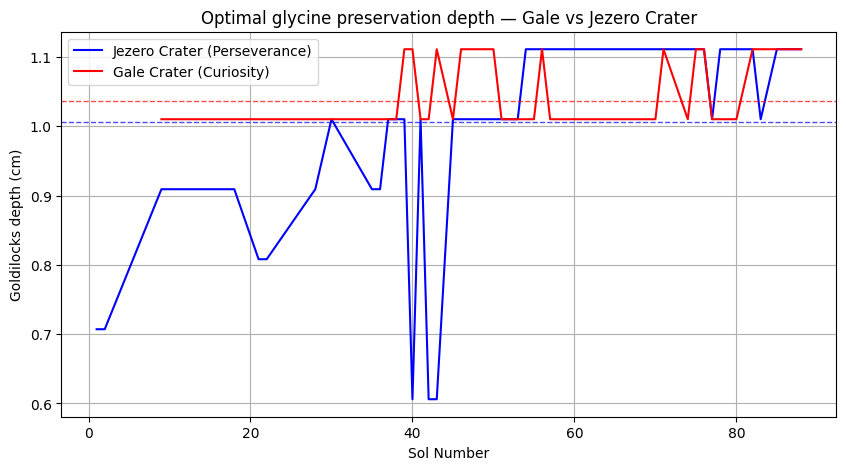

In [35]:
plt.figure(figsize=(10,5))
plt.plot(uv_jezero_per_sol.index, goldilocks_jezero,
         'b-', linewidth=1.5, label='Jezero Crater (Perseverance)')
plt.plot(uv_jezero_per_sol.index, goldilocks_gale,
         'r-', linewidth=1.5, label='Gale Crater (Curiosity)')
plt.axhline(np.mean(goldilocks_jezero), color='blue',
            linestyle='--', linewidth=1, alpha=0.7)
plt.axhline(np.nanmean(goldilocks_gale), color='red',
            linestyle='--', linewidth=1, alpha=0.7)
plt.xlabel('Sol Number')
plt.ylabel('Goldilocks depth (cm)')
plt.title('Optimal glycine preservation depth — Gale vs Jezero Crater')
plt.legend()
plt.grid(True)
plt.show()

### 15. Distribution Analysis

We examine whether the Goldilocks depth distribution is symmetric across sols, and calculate the median as a more robust central estimate than the mean.

Mean: 1.035 cm
Median: 1.010 cm
Std: 0.057 cm


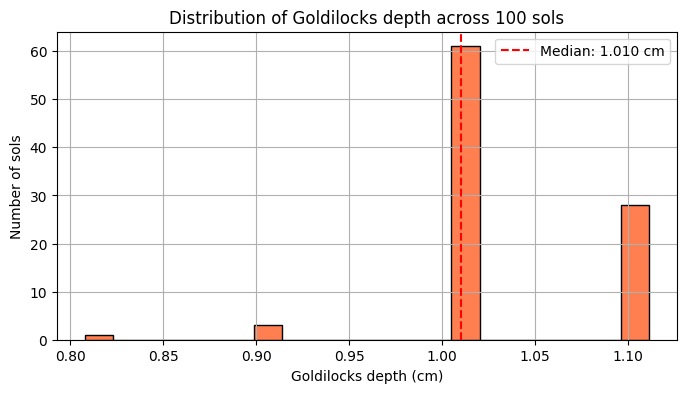

In [36]:
# Check if Goldilocks distribution is symmetric
print(f"Mean: {np.mean(goldilocks_per_sol):.3f} cm")
print(f"Median: {np.median(goldilocks_per_sol):.3f} cm")
print(f"Std: {np.std(goldilocks_per_sol):.3f} cm")

plt.figure(figsize=(8,4))
plt.hist(goldilocks_per_sol, bins=20, edgecolor='black', color='coral')
plt.xlabel('Goldilocks depth (cm)')
plt.ylabel('Number of sols')
plt.title('Distribution of Goldilocks depth across 100 sols')
plt.axvline(np.median(goldilocks_per_sol), color='red', linestyle='--', label=f'Median: {np.median(goldilocks_per_sol):.3f} cm')
plt.legend()
plt.grid(True)
plt.show()

### 16. Sensitivity Analysis

Each model parameter is varied individually (0.5–2.0×, or 0.8–1.2× for Ea) while holding others constant. This identifies which parameters most strongly influence the Goldilocks depth and therefore represent the highest priorities for future experimental measurement.

In [37]:
# === SENSITIVITY ANALYSIS ===
# Vary one parameter at a time, measure effect on Goldilocks depth

baseline_depth = 1.01  # our real-data result

# Parameters to vary
variations = {
    'sigma (UV cross-section)': (sigma, 0.5, 2.0),
    'alpha (rad sensitivity)': (alpha, 0.5, 2.0),
    'Ea (activation energy)': (45000, 0.8, 1.2),
    'F_UV (UV flux)': (F_UV_real, 0.5, 2.0),
    'lambda (UV attenuation)': (0.1, 0.5, 2.0),
}

print(f"{'Parameter':<30} {'Low':<10} {'High':<10} {'Depth Low':<12} {'Depth High':<12} {'Sensitivity'}")
print("="*90)

for name, (base_val, low_mult, high_mult) in variations.items():
    results = []
    for mult in [low_mult, high_mult]:
        val = base_val * mult
        if 'sigma' in name:
            kz = val * F_UV_real * np.exp(-depths/0.1)
        elif 'alpha' in name:
            kz = sigma * F_UV_real * np.exp(-depths/0.1)
        elif 'F_UV' in name:
            kz = sigma * val * np.exp(-depths/0.1)
        elif 'lambda' in name:
            kz = sigma * F_UV_real * np.exp(-depths/val)
        else:
            kz = sigma * F_UV_real * np.exp(-depths/0.1)

        if 'alpha' in name:
            kr = val * dose_rate * np.exp(-depths/3.0)
        else:
            kr = k_rad * np.exp(-depths/3.0)

        if 'Ea' in name:
            kt = 1e8 * np.exp(-val/(8.314*(210+0.1*depths)))
        else:
            kt = 1e8 * np.exp(-45000/(8.314*(210+0.1*depths)))

        k_tot = kz + kr + kt
        hl = np.log(2) / k_tot
        results.append(depths[np.argmax(hl)])

    sensitivity = abs(results[1] - results[0])
    print(f"{name:<30} {low_mult:<10} {high_mult:<10} {results[0]:<12.2f} {results[1]:<12.2f} {sensitivity:.2f} cm")

Parameter                      Low        High       Depth Low    Depth High   Sensitivity
sigma (UV cross-section)       0.5        2.0        1.01         1.11         0.10 cm
alpha (rad sensitivity)        0.5        2.0        1.01         1.01         0.00 cm
Ea (activation energy)         0.8        1.2        0.61         1.62         1.01 cm
F_UV (UV flux)                 0.5        2.0        1.01         1.11         0.10 cm
lambda (UV attenuation)        0.5        2.0        0.61         1.92         1.31 cm


### 17. Refined Model — Realistic Subsurface Temperature

The initial model used a geothermal gradient of 0.1 K/cm. The actual Martian gradient is ~5 K/km (0.005 K/m), meaning temperature in the top 10 cm is effectively constant at the mean surface value of 210 K. This correction changes the curve from a peak-and-decline to a plateau, yielding a minimum effective shielding depth (where half-life reaches 95% of maximum) rather than an optimal peak.

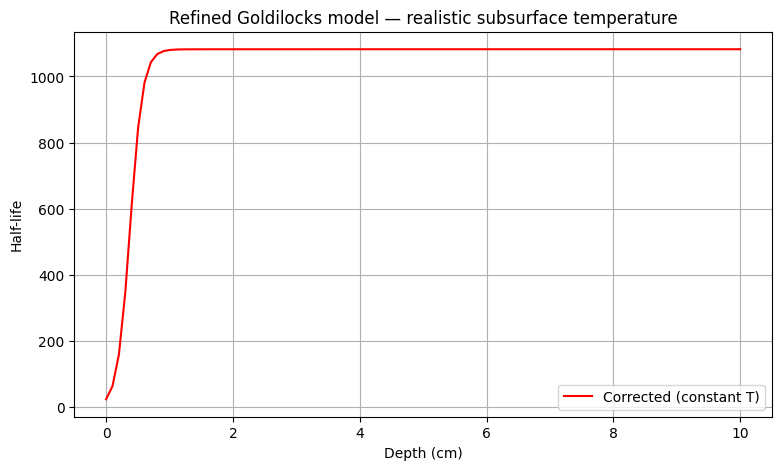

Minimum effective shielding depth: 0.71 cm
Half-life plateaus beyond this depth


In [38]:
# === REFINED MODEL — Realistic constant subsurface temperature ===
# In the top 10 cm of Mars, temperature is constant at the mean (~210K)
# The geothermal gradient only applies at metre-scale depths

depths = np.linspace(0, 10, 100)

# Real UV from Curiosity
k_UV_z = sigma * F_UV_real * np.exp(-depths / 0.1)
k_rad_z = k_rad * np.exp(-depths / 3.0)

# CORRECTED: constant temperature in top 10 cm
T_z = 210 * np.ones_like(depths)
k_thermal_z = 1e8 * np.exp(-45000 / (8.314 * T_z))

k_total_z = k_UV_z + k_rad_z + k_thermal_z
half_life_z = np.log(2) / k_total_z

plt.figure(figsize=(9,5))
plt.plot(depths, half_life_z, 'r-', label='Corrected (constant T)')
plt.xlabel('Depth (cm)')
plt.ylabel('Half-life')
plt.title('Refined Goldilocks model — realistic subsurface temperature')
plt.grid(True)
plt.legend()
plt.show()

# Find minimum effective depth (where half-life reaches 95% of max)
max_hl = np.max(half_life_z)
threshold_idx = np.argmax(half_life_z > 0.95 * max_hl)
min_effective_depth = depths[threshold_idx]
print(f"Minimum effective shielding depth: {min_effective_depth:.2f} cm")
print(f"Half-life plateaus beyond this depth")